In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)

import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


In [2]:
CSV_HOTEL_PATH = "../../data/raw/dataset.csv"
df_hotel = pd.read_csv(CSV_HOTEL_PATH)

## PREPROCESAMIENTO DE DATOS

In [3]:
df_hotel_prep = df_hotel.copy()

In [4]:

# Remove duplicates
print(f"Shape before removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number before: {df_hotel_prep.duplicated(keep=False).sum()}")
df_hotel_prep = df_hotel_prep.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Shape after removing duplicates: {df_hotel_prep.shape}")
print(f"Duplicated number after: {df_hotel_prep.duplicated(keep=False).sum()}")

Shape before removing duplicates: (119390, 32)
Duplicated number before: 40165
Shape after removing duplicates: (87396, 32)
Duplicated number after: 0


In [5]:
df_hotel_prep['children'] = df_hotel_prep['children'].fillna(0)

In [ ]:
# Borrado columnas
drop_columns = [
   'company',
   'arrival_date_year',          # Sobreajusta a años concretos
   'arrival_date_week_number',   # Redundante con mes
   'arrival_date_day_of_month',  # Ruido
   'reservation_status_date',    # Es post-evento, data leakage
   'reservation_status',         # Puede provocar overfitting
]
df_hotel_prep.drop(columns=drop_columns, inplace=True)

# Filas con precio negativo: outlier imposible que distorsiona el escalado
df_hotel_prep = df_hotel_prep[df_hotel_prep['adr'] >= 0].reset_index(drop=True)

# Reservas sin ningún huésped: datos incoherentes (children puede tener NaN aquí, tratado con fillna)
df_hotel_prep = df_hotel_prep[
    df_hotel_prep['adults'].fillna(0) + df_hotel_prep['children'].fillna(0) + df_hotel_prep['babies'].fillna(0) > 0
].reset_index(drop=True)

print(f"Shape tras limpieza de filas inválidas: {df_hotel_prep.shape}")

Shape tras limpieza de filas inválidas: (87229, 26)


In [7]:
# Agrupar los paises con frecuencia < 1%
frequencies = df_hotel_prep['country'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['country'] = np.where(
    df_hotel_prep['country'].isna() | df_hotel_prep['country'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['country']
)
print(f"{df_hotel_prep['country'].value_counts(normalize=True)}")

country
PRT       0.313600
Others    0.119937
GBR       0.119490
FRA       0.101148
ESP       0.083046
DEU       0.061734
ITA       0.035092
IRL       0.034564
BEL       0.023857
BRA       0.022848
NLD       0.021896
USA       0.021449
CHE       0.017953
CN        0.012530
AUT       0.010856
Name: proportion, dtype: float64


In [8]:
# Agrupar los canales de distribución con frecuencia < 1% (Undefined -> news)
df_hotel_prep['distribution_channel'] = df_hotel_prep['distribution_channel'].replace('Undefined', 'news')

frequencies = df_hotel_prep['distribution_channel'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies < 0.01].index
df_hotel_prep['distribution_channel'] = np.where(
    df_hotel_prep['distribution_channel'].isna() | df_hotel_prep['distribution_channel'].isin(index_low_frequency),
    'others',
    df_hotel_prep['distribution_channel']
)
print(f"{df_hotel_prep['distribution_channel'].value_counts(normalize=True)}")

distribution_channel
TA/TO        0.791342
Direct       0.148494
Corporate    0.058031
others       0.002132
Name: proportion, dtype: float64


In [9]:
# Agrupar el segmento de mercado con frecuencia <= 1%
frequencies = df_hotel_prep['market_segment'].value_counts(normalize=True)
index_low_frequency = frequencies[frequencies <= 0.01].index
df_hotel_prep['market_segment'] = np.where(
    df_hotel_prep['market_segment'].isna() | df_hotel_prep['market_segment'].isin(index_low_frequency),
    'Others',
    df_hotel_prep['market_segment']
)
print(f"{df_hotel_prep['market_segment'].value_counts(normalize=True)}")

market_segment
Online TA        0.591008
Offline TA/TO    0.158835
Direct           0.135047
Groups           0.056415
Corporate        0.048149
Others           0.010547
Name: proportion, dtype: float64


In [ ]:
# Nueva columna indicando si ambas coinciden
df_hotel_prep['reserved_assigned_room'] = (df_hotel_prep['reserved_room_type'] == df_hotel_prep['assigned_room_type']).astype(int)
df_hotel_prep['reserved_assigned_room']

# SOLO PARA REGRESION LOGISTICA O REDES NEURONALES
df_hotel_prep.drop(columns=['assigned_room_type'], inplace=True)

In [11]:
df_hotel_prep['agent_known'] = df_hotel_prep['agent'].notna().astype(int)
df_hotel_prep.drop(columns=['agent'], inplace=True)
print(f"agent_known distribution:\n{df_hotel_prep['agent_known'].value_counts(normalize=True)}")

agent_known distribution:
agent_known
1    0.860815
0    0.139185
Name: proportion, dtype: float64



#### APLICAR METODOS PARA EVITAR SESGOS

In [12]:
# lead_time tiene distribución muy sesgada a la derecha (cola hasta ~700 días);
# log1p linealiza la relación con la cancelación para la LR, que no puede capturarla sola
df_hotel_prep['lead_time_log'] = np.log1p(df_hotel_prep['lead_time'])
df_hotel_prep.drop(columns=['lead_time'], inplace=True)

In [13]:
MONTHS = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
          'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}
month_num = df_hotel_prep['arrival_date_month'].map(MONTHS)
df_hotel_prep['month_sin'] = np.sin(2 * np.pi * month_num / 12)
df_hotel_prep['month_cos'] = np.cos(2 * np.pi * month_num / 12)

In [14]:
df_hotel_prep.drop(columns=['arrival_date_month'], inplace=True)

In [15]:
df_hotel_prep['children'] = df_hotel_prep['children'].clip(upper=df_hotel_prep['children'].quantile(0.99))
print(f"Agrupacion de children (quartil 99): {df_hotel_prep['children'].value_counts(normalize=True)}")

df_hotel_prep['adults'] = df_hotel_prep['adults'].clip(upper=df_hotel_prep['adults'].quantile(0.99))
print(f"Agrupacion de adults (quartil 99): {df_hotel_prep['adults'].value_counts(normalize=True)}")

df_hotel_prep['babies'] = df_hotel_prep['babies'].clip(upper=df_hotel_prep['babies'].quantile(0.99))
print(f"Agrupacion de babies (quartil 99): {df_hotel_prep['babies'].value_counts(normalize=True)}")

df_hotel_prep['adr'] = df_hotel_prep['adr'].clip(upper=df_hotel_prep['adr'].quantile(0.99))
print(f"Agrupacion de adr (quartil 99): {df_hotel_prep['adr'].value_counts(normalize=True)}")

Agrupacion de children (quartil 99): children
0.0    0.904114
1.0    0.053824
2.0    0.042062
Name: proportion, dtype: float64
Agrupacion de adults (quartil 99): adults
2    0.739387
1    0.189192
3    0.068911
0    0.002511
Name: proportion, dtype: float64
Agrupacion de babies (quartil 99): babies
0    0.989522
1    0.010478
Name: proportion, dtype: float64
Agrupacion de adr (quartil 99): adr
0.0000      0.018835
75.0000     0.015133
65.0000     0.014445
48.0000     0.010065
261.6224    0.010008
              ...   
55.1100     0.000011
33.6500     0.000011
31.4100     0.000011
31.8000     0.000011
157.7100    0.000011
Name: proportion, Length: 8516, dtype: float64


#### Obtener variables X e y

In [16]:
random_state=11
target_column = 'is_canceled'
X = df_hotel_prep.drop(columns=[target_column])
y = df_hotel_prep[target_column]

print(f"Percentage y: {y.value_counts(normalize=True)}")

Percentage y: is_canceled
0    0.724759
1    0.275241
Name: proportion, dtype: float64


In [ ]:
model_lr = LogisticRegression(C=0.05, max_iter=700, penalty='l2', solver='liblinear', random_state=random_state, class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)


# OHE se aplica después del split (fit solo con train) para evitar leakage
category_columns = ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type',
                    'deposit_type', 'customer_type']
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[category_columns])
train_ohe = pd.DataFrame(ohe.transform(X_train[category_columns]), columns=ohe.get_feature_names_out(category_columns), index=X_train.index)
test_ohe  = pd.DataFrame(ohe.transform(X_test[category_columns]),  columns=ohe.get_feature_names_out(category_columns), index=X_test.index)
X_train = pd.concat([X_train.drop(columns=category_columns), train_ohe], axis=1)
X_test  = pd.concat([X_test.drop(columns=category_columns),  test_ohe],  axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f"Train data percentage: {y_train.value_counts(normalize=True)}")
print(f"Test data percentage:  {y_test.value_counts(normalize=True)}")

model_lr = model_lr.fit(X_train_scaled, y_train)

Train data percentage: is_canceled
0    0.724761
1    0.275239
Name: proportion, dtype: float64
Test data percentage:  is_canceled
0    0.724751
1    0.275249
Name: proportion, dtype: float64


In [47]:
y_predict = model_lr.predict(X_test_scaled)
y_predict_proba = model_lr.predict_proba(X_test_scaled)

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_predict)
prec = precision_score(y_test, y_predict)
rec = recall_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_predict_proba[:, 1])

print(f"Accuracy (Cancelaciones sobre el total):  {acc:.2%}")
print(f"Precisión (Cancelaciones predichas acertadas): {prec:.2%}")
print(f"Recall (Cancelaciones predichas vs reales):    {rec:.2%}")
print(f"F1-Score (media entre precision y recall):  {f1:.2%}")
print(f"AUC:       {auc:.2%}\n")

Accuracy (Cancelaciones sobre el total):  76.48%
Precisión (Cancelaciones predichas acertadas): 54.84%
Recall (Cancelaciones predichas vs reales):    82.30%
F1-Score (media entre precision y recall):  65.82%
AUC:       86.00%



In [20]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_predict))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.74      0.82     12644
           1       0.55      0.82      0.66      4802

    accuracy                           0.76     17446
   macro avg       0.73      0.78      0.74     17446
weighted avg       0.82      0.76      0.78     17446



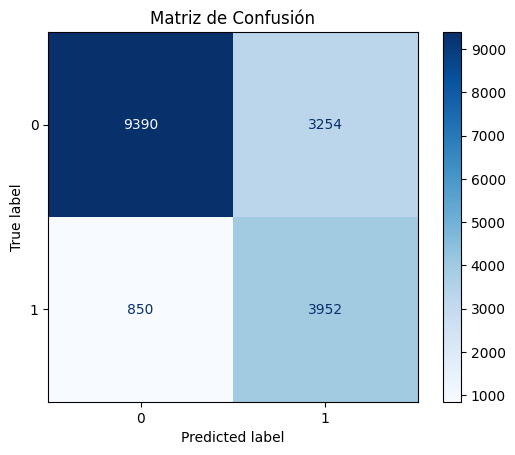

In [22]:
cm = confusion_matrix(y_test, y_predict)

# 3. Mostrarla de forma visual y bonita
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_lr.classes_)
disp.plot(cmap='Blues')

plt.title(f'Matriz de Confusión')
plt.show()

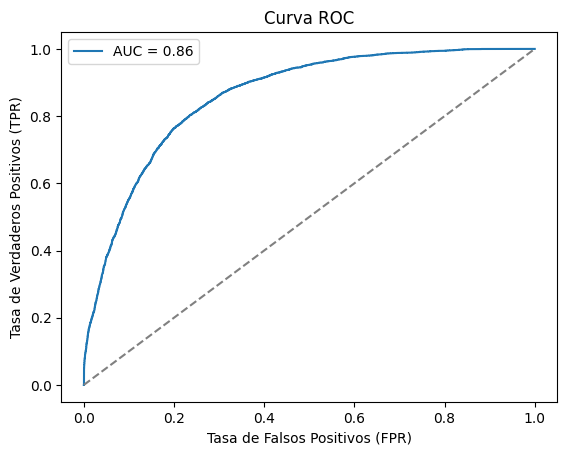

In [23]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_predict_proba[:, 1])
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()